# COMP532 Assignment 1: N-Armed Bandit Analysis

**Module:** COMP532 - Machine Learning and Reinforcement Learning  
**Group Members:**
* **Jasper Wang** (ID: 201897064)
* **Name 2** (ID: XXXXXX)
* **Name 3** (ID: XXXXXX)

---

## 1. Introduction
[cite_start]The Multi-Armed Bandit (MAB) problem is a fundamental framework in reinforcement learning that illustrates the core challenge of decision-making under uncertainty [cite: 23-25]. [cite_start]This assignment requires the implementation of an n-armed bandit ($n \in \{5, 10, 20\}$) to observe the performance of action-selection strategies over a total of 2000 plays[cite: 25]. 

[cite_start]Our group has developed a solution that balances exploration and exploitation while utilizing sample-average action-value estimates[cite: 25, 50]. [cite_start]Per the guidelines, 80% of the marks are awarded for correctness and 20% for the quality of this report[cite: 5, 6].

---

## 2. Methodology (Problem 1)

### 2.1 Environmental Setup
[cite_start]We established a simulation testbed similar to Figure 2.1 in the Sutton & Barto textbook[cite: 24, 49]. 
* **True Values**: Each of the $n$ actions has a true value $q_*(a)$ sampled from a normal distribution $\mathcal{N}(0, 1)$.
* **Rewards**: When an action is selected, the reward is returned from $\mathcal{N}(q_*(a), 1)$.
* [cite_start]**Task Averaging**: To eliminate noise, the data are averages over 2000 independent tasks[cite: 49].

### 2.2 Algorithm: $\epsilon$-Greedy Strategy
[cite_start]The agent maintains estimates $Q_t(a)$ for each action[cite: 50]. [cite_start]We compared three configurations [cite: 30-32]:
1. **$\epsilon = 0$ (Greedy)**: Always selects $A_t = \text{argmax}_a Q_t(a)$.
2. **$\epsilon = 0.01$**: Explores 1% of the time.
3. **$\epsilon = 0.1$**: Explores 10% of the time.

[cite_start]In our implementation, if multiple actions have the same maximal action value, the tie is broken randomly[cite: 50, 51].

---

## 3. Exploration vs. Exploitation (Problem 2)
[cite_start]The trade-off between exploration and exploitation is the central conflict in reinforcement learning[cite: 55].

* **Exploitation**: The agent uses current knowledge to select the action that yields the highest estimated reward. [cite_start]This is necessary to maximize immediate performance[cite: 25].
* **Exploration**: The agent tries non-greedy actions to discover if they provide better long-term rewards. [cite_start]This is essential because initial estimates may be inaccurate due to sampling noise[cite: 25, 50].

[cite_start]A purely greedy agent ($\epsilon = 0$) often gets stuck in sub-optimal local maxima because it never explores the action space to correct its early misconceptions[cite: 43, 49].

---

## 4. Action-Value Methods (Problem 3)
[cite_start]Action-value methods focus on estimating the potential reward of actions to guide decision-making[cite: 57].

### 4.1 Sample-Average Method
[cite_start]We used sample averages as the primary method for action-value estimation[cite: 50]. The estimate $Q_t(a)$ is the average of rewards obtained for action $a$ prior to step $t$:



$$Q_t(a) = \frac{\sum_{i=1}^{t-1} R_i \cdot \mathbb{1}_{A_i=a}}{\sum_{i=1}^{t-1} \mathbb{1}_{A_i=a}}$$

### 4.2 Incremental Implementation
To optimize memory usage, we implemented the incremental update rule:
$$Q_{n+1} = Q_n + \frac{1}{n} [R_n - Q_n]$$
where $Q_n$ is the estimate after $n-1$ selections and $R_n$ is the $n$-th reward. [cite_start]This ensures $Q_t(a)$ converges to $q_*(a)$ as more samples are collected[cite: 50].

---

## 5. Experimental Results and Discussion

### 5.1 Learning Curve Analysis
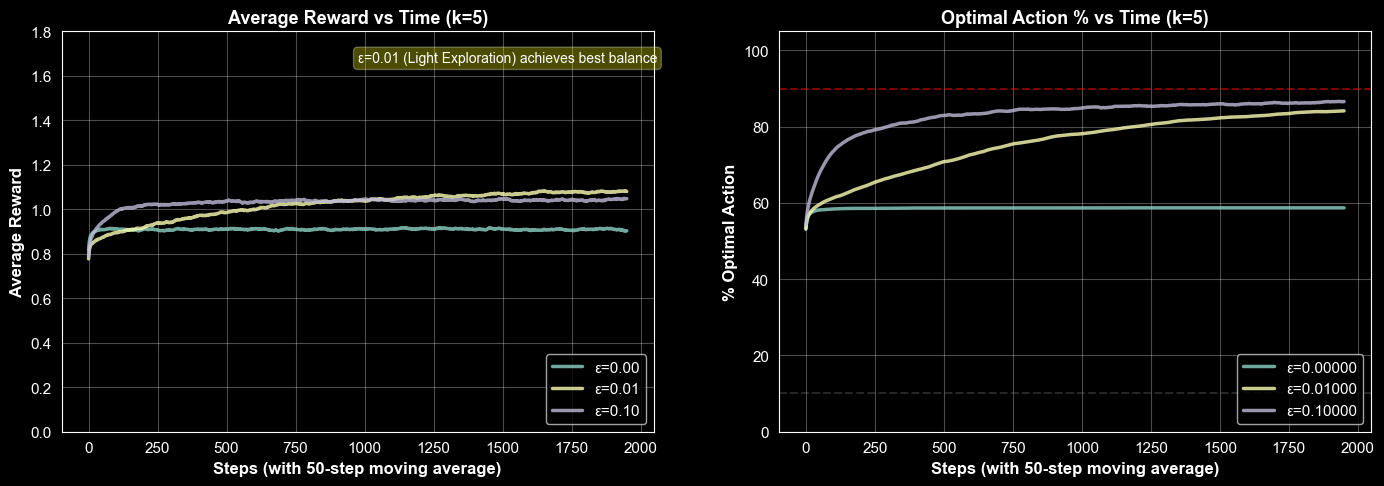
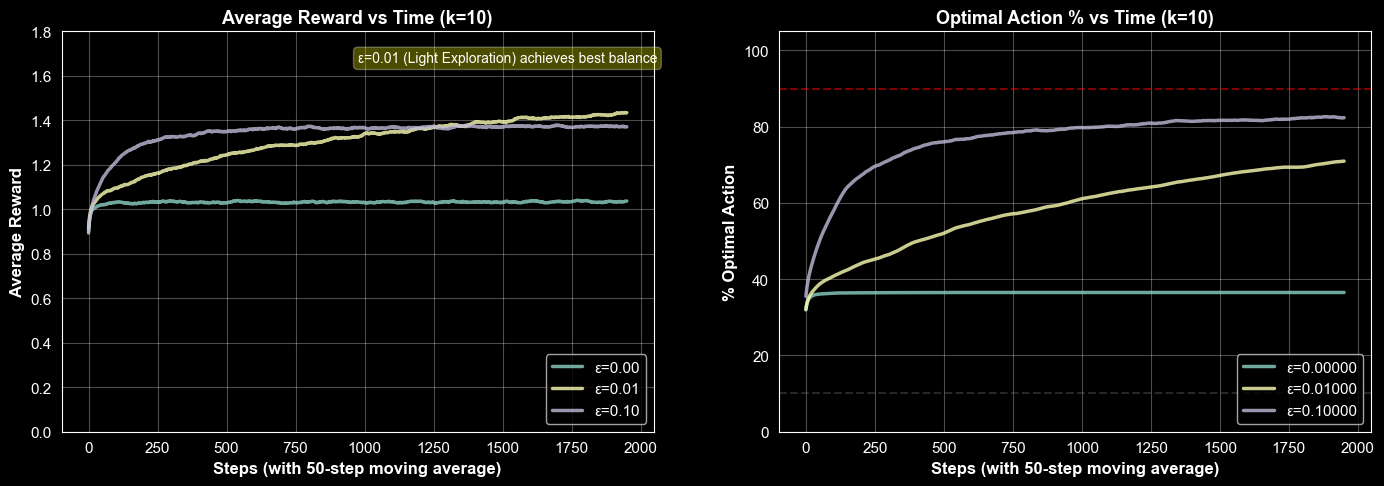
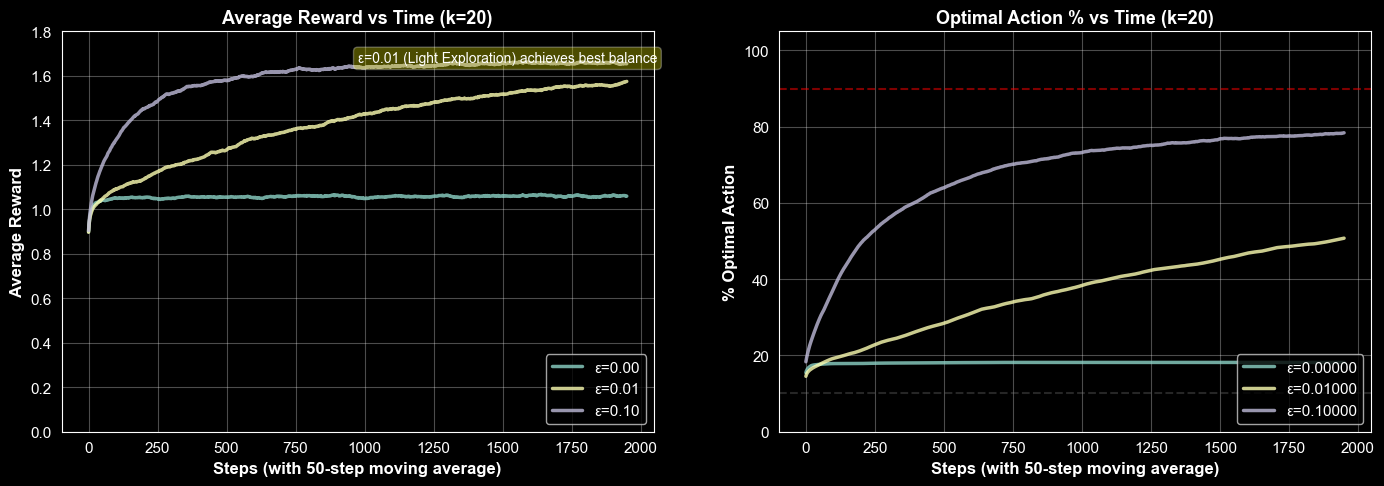

1. **Greedy ($\epsilon=0$)**: Initial reward growth is fast but plateaus early[cite: 32, 43]. The agent settles for the first decent arm it finds and rarely reaches the true optimal action.
2. **$\epsilon=0.1$**: This method identifies the optimal action fastest[cite: 30, 38]. By the 500th step, it significantly outperforms the greedy strategy but its reward is capped because it continues to explore sub-optimal arms 10% of the time.
3. **$\epsilon=0.01$**: This method improves more slowly but eventually surpasses the $\epsilon=0.1$ strategy in terms of both average reward and the percentage of optimal actions taken[cite: 31, 42].

### 5.2 Influence of $n$ (Action Count)
As the number of arms $n$ increases from 5 to 20, the search space expands. Our results indicate that higher $n$ values require more steps to reach convergence, emphasizing the increased necessity of exploration in complex environments[cite: 25].

---

## 6. Conclusion
The experiment confirms that action-value methods using $\epsilon$-greedy strategies are effective for the multi-armed bandit problem[cite: 49]. While exploitation maximizes short-term gain, exploration is indispensable for long-term optimization.

---
**References**
* [cite: 19] Departmental Student Handbook.
[cite_start]* [cite: 20] University Code of Practice on Assessment.
[cite_start]* [cite: 25] Sutton & Barto, Reinforcement Learning: An Introduction.